<a href="https://colab.research.google.com/github/databyhuseyn/MachineLearning/blob/main/California_Housing_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
#!/bin/bash
!curl -L -o california-housing-prices.zip https://www.kaggle.com/api/v1/datasets/download/camnugent/california-housing-prices

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  399k  100  399k    0     0  1572k      0 --:--:-- --:--:-- --:--:-- 1572k


In [22]:
from zipfile import ZipFile

In [23]:
with ZipFile('california-housing-prices.zip', 'r') as f:
  f.extractall()

In [24]:
!ls

california-housing-prices.zip  housing.csv  sample_data


In [25]:
import pandas as pd

In [26]:
df = pd.read_csv('housing.csv')
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [27]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [29]:
df['housing_median_age'].loc[df['housing_median_age'] >= 50] = None

/tmp/ipykernel_3527/1780839600.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['housing_median_age'].loc[df['housing_median_age'] >= 50] = None
/tmp/ipykernel_3527/1780839600.py:1: SettingWithCopyWarning: 
A value is trying to be set 

In [30]:
df['median_house_value'].loc[df['median_house_value'] >= 500_000] = None

/tmp/ipykernel_3527/1230741635.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['median_house_value'].loc[df['median_house_value'] >= 500_000] = None
/tmp/ipykernel_3527/1230741635.py:1: SettingWithCopyWarning: 
A value is trying to be

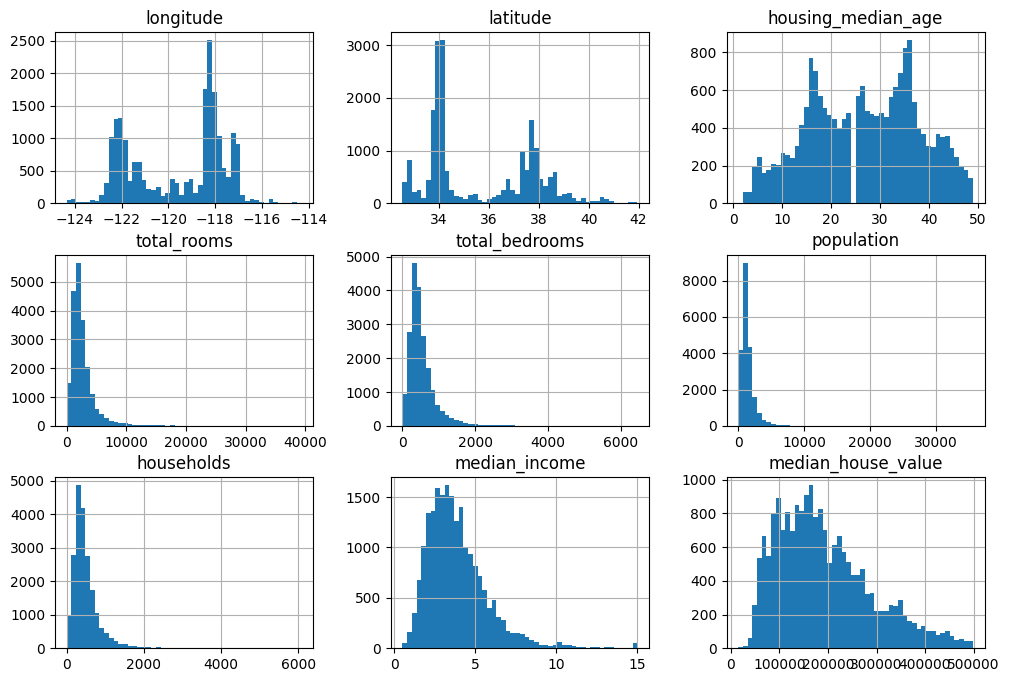

In [32]:
df.hist(bins=50, figsize=(12, 8));

In [34]:
import numpy as np

<Axes: >

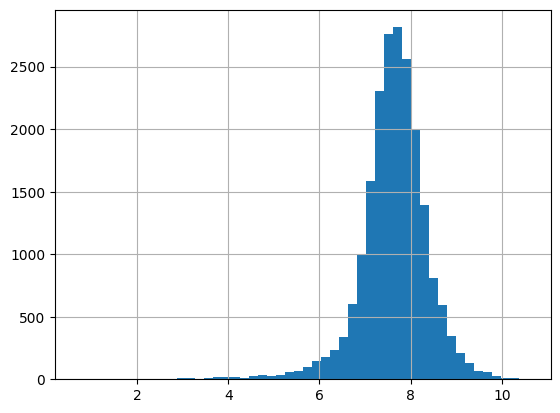

In [39]:
np.log(df['total_rooms']).hist(bins=50)

<Axes: >

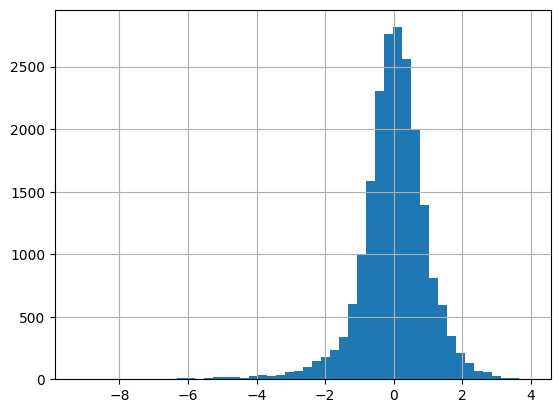

In [43]:
((np.log(df['total_rooms']) - np.log(df['total_rooms']).mean()) / np.log(df['total_rooms']).std()).hist(bins=50) # StandardScaler

<Axes: >

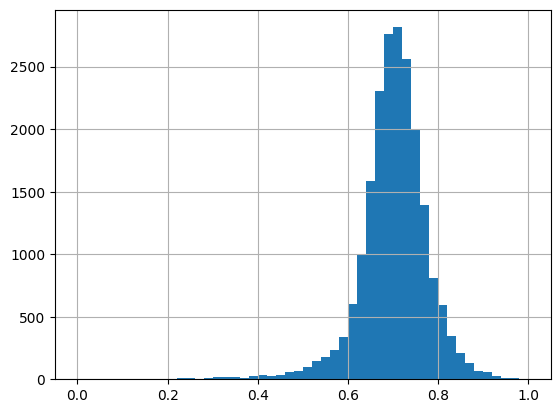

In [44]:
((np.log(df['total_rooms']) - np.log(df['total_rooms']).min()) / (np.log(df['total_rooms']).max()- np.log(df['total_rooms']).min())).hist(bins=50) # MinMaxScaler

In [48]:
columns_to_transform = ['total_rooms', 'total_bedrooms', 'population', 'households']

for column in columns_to_transform:
  df[column] = np.log(df[column])

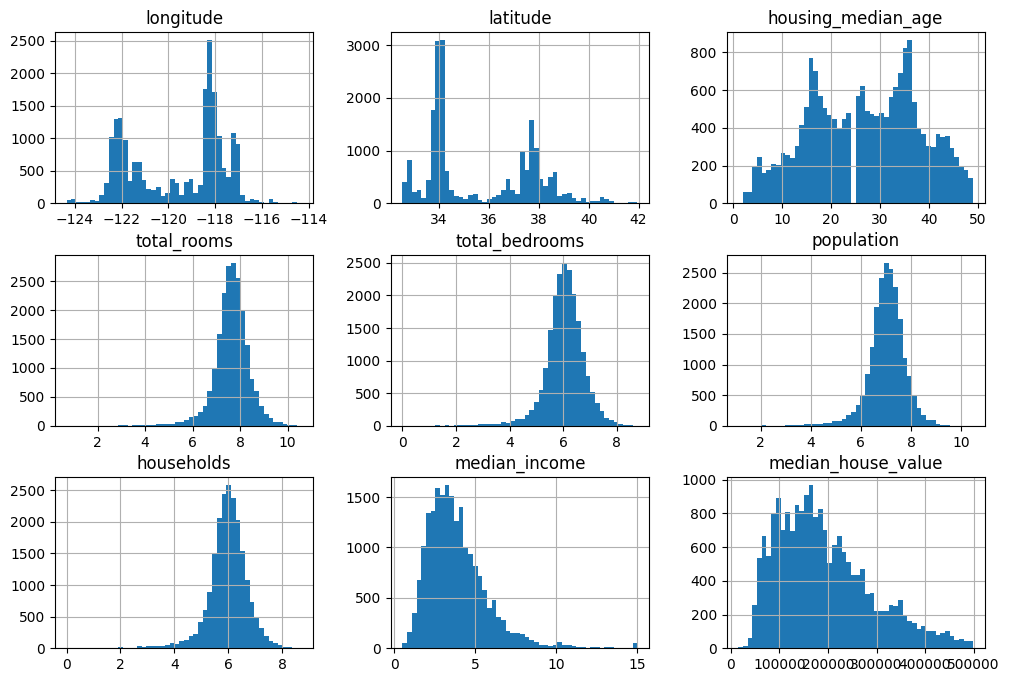

In [59]:
df.hist(bins=50, figsize=(12, 8));

In [51]:
df.isna().sum()

,0
longitude,0
latitude,0
housing_median_age,1457
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,992
ocean_proximity,0


In [52]:
from sklearn.preprocessing import QuantileTransformer

In [53]:
quantile = QuantileTransformer(output_distribution='normal', random_state=42)

In [57]:
import matplotlib.pyplot as plt

(array([1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 2.000e+00, 1.000e+01, 2.200e+01, 4.300e+01,
        4.700e+01, 1.080e+02, 1.730e+02, 2.950e+02, 3.430e+02, 4.940e+02,
        6.290e+02, 9.800e+02, 1.081e+03, 1.362e+03, 1.485e+03, 1.645e+03,
        1.700e+03, 1.687e+03, 1.539e+03, 1.543e+03, 1.273e+03, 1.138e+03,
        9.070e+02, 6.820e+02, 5.000e+02, 3.270e+02, 2.240e+02, 1.610e+02,
        8.600e+01, 6.700e+01, 4.000e+01, 1.400e+01, 4.000e+00, 0.000e+00,
        4.000e+00, 6.000e+00, 6.000e+00, 2.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+01]),
 array([-5.19933758e+00, -4.99136408e+00, -4.78339058e+00, -4.57541707e+00,
        -4.36744357e+00, -4.15947007e+00, -3.95149656e+00, -3.74352306e+00,
        -3.53554956e+00, -3.32757605e+00, -3.11960255e+00, -2.91162905e+00,
        -2.70365554e+00, -2.49568204e+00, -2.28770854e+00, -2.07973503e+00,
        -1.87176153e+00, -1.66378803e+00, -1.45581452e+00, -1.24784102e+

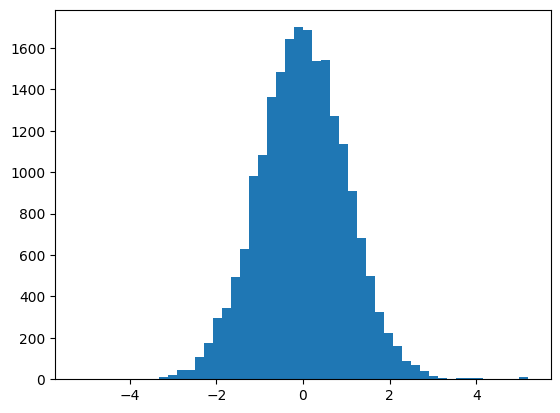

In [58]:
plt.hist(quantile.fit_transform(df[['longitude']]), bins=50)

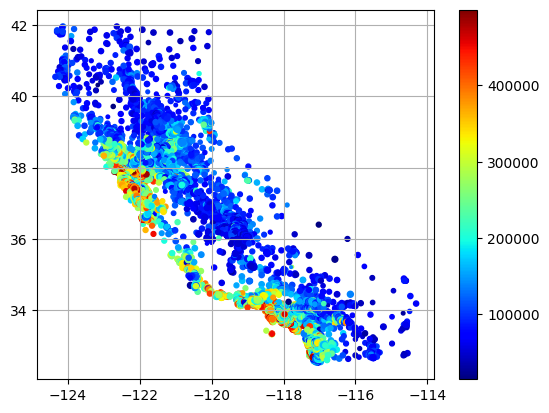

In [70]:
plt.scatter(df['longitude'],
            df['latitude'],
            c=df['median_house_value'],
            cmap='jet',
            s=df['population'] * 2)
plt.grid()
plt.colorbar();

In [76]:
df.isna().sum()

,0
longitude,0
latitude,0
housing_median_age,1260
total_rooms,0
total_bedrooms,200
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [75]:
df.dropna(subset = ['median_house_value'], inplace=True)

In [77]:
X = df.drop(['median_house_value'], axis=1)
y = df['median_house_value'].copy()

In [78]:
from sklearn.model_selection import train_test_split

In [81]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [82]:
df['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,8595
INLAND,6523
NEAR OCEAN,2437
NEAR BAY,2088
ISLAND,5


In [83]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor

In [84]:
num_features = X_train.select_dtypes(include=[np.number]).columns
cat_features = X_train.select_dtypes(exclude=[np.number]).columns

In [86]:
num_features

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='object')

In [101]:
num_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

cat_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

transformer = ColumnTransformer([
    ('cat', cat_pipeline, cat_features),
    ('num', num_pipeline, num_features)
], remainder='passthrough')

model = RandomForestRegressor()

full_pipeline = Pipeline([
    ('preprocessing', transformer),
    ('estimator', model)
])

In [102]:
full_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['ocean_proximity'], dtype='object'))])),
                ('estimator', RandomForestRegressor())])

In [103]:
print(f'Train score: {full_pipeline.score(X_train, y_train)}\nTest score: {full_pipeline.score(X_test, y_test)}')

Train score: 0.9711448936970479
Test score: 0.7911884202998626


In [31]:
# Hyperparameter Tuning

In [94]:
from sklearn.model_selection import GridSearchCV # RandomizedSearchCV

In [108]:
param_grid = {
    "estimator__n_estimators": range(40, 141, 20),
    "estimator__criterion": ['squared_error', 'absolute_error', 'poisson'],
    "estimator__max_depth": [3, 5, 7, 10]
}

gscv = GridSearchCV(full_pipeline, param_grid, cv=3)

In [111]:
gscv.fit(X_train[:100], y_train[:100])

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         Pipeline(steps=[('impute',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scale',
                                                                                          StandardScaler())]),
                                                                         Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='objec...
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         Index(['ocean_proximity'], dtype='object'))])),
                                       ('estimator', RandomForestRegressor())]),
             param_grid={'estimator__criterion': ['squared_error',
                                                  'absolute_error', 'poisson'],
                         'estimator__max_depth': [3, 5, 7, 10],
                         'estimator__n_estimators': range(40, 141, 20)})

In [112]:
gscv.best_params_

{'estimator__criterion': 'absolute_error',
 'estimator__max_depth': 10,
 'estimator__n_estimators': 40}

In [113]:
gscv.best_estimator_

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['ocean_proximity'], dtype='object'))])),
                ('estimator',
                 RandomForestRegressor(criterion='absolute_error', max_depth=10,
                                       n_estimators=40))])

In [114]:
gscv.best_score_

np.float64(0.3421326569500424)

In [115]:
best_model = gscv.best_estimator_
best_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['ocean_proximity'], dtype='object'))])),
                ('estimator',
                 RandomForestRegressor(criterion='absolute_error', max_depth=10,
                                       n_estimators=40))])

In [116]:
print(f'Train score: {best_model.score(X_train, y_train)}\nTest score: {best_model.score(X_test, y_test)}')

Train score: 0.8266059439618986
Test score: 0.7512679392881095
